# A Light Weight Multi-Distance fNIRS Dataset for Ball-Squeezing Task and Purposeful Motion Artifact Creation

## Imports

In [10]:
# PyTorch
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as nnFunc
from torchviz import make_dot
# General
import numpy as np
import matplotlib.pyplot as plt
# Read Dataset
import mne
import mne_nirs
import os
import openneuro

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 13.0


## Dataset
[link](https://openneuro.org/datasets/ds007420) to dataset

### 1. Download Dataset

In [11]:
dataset_id = 'ds007420'
target_folder = './heg_full_data'

# dataset_description.json is the metadata 'heart' of the folder
marker_file = os.path.join(target_folder, 'dataset_description.json')

# Check if the folder and the marker file exist
if os.path.exists(target_folder) and os.path.isfile(marker_file):
    print(f"Dataset {dataset_id} already exists in '{target_folder}'. Skipping download.")
else:
    print(f"Dataset not found or incomplete. Starting download to '{target_folder}'...")
    try:
        # The openneuro-py library will fetch the actual binary data
        openneuro.download(dataset=dataset_id, target_dir=target_folder)
        print("Download successfully completed!")
    except Exception as e:
        print(f"An error occurred during download: {e}")

print("Ready to process data.")

Dataset ds007420 already exists in './heg_full_data'. Skipping download.
Ready to process data.


### 1. Load Dataset

Loading d:\Education\PhD\Courses\3_DeepLearning\Assignments\Repo\202610ELC536501\Project\heg_full_data\sub-170\ses-01\nirs\sub-170_ses-01_task-Resting_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 2655  =      0.000 ...   304.497 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.01
- Lower transition bandwidth: 0.01 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 0.70 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.70 Hz)
- Filter length: 2879 samples (330.187 s)

Using matplotlib as 2D backend.


C:\Users\kaveh\AppData\Local\Temp\ipykernel_22428\1354355174.py:12: RuntimeWarning: filter_length (2879) is longer than the signal (2656), distortion is likely. Reduce filter length or filter a longer signal.
  raw_od.filter(0.01, 0.7, fir_design='firwin')


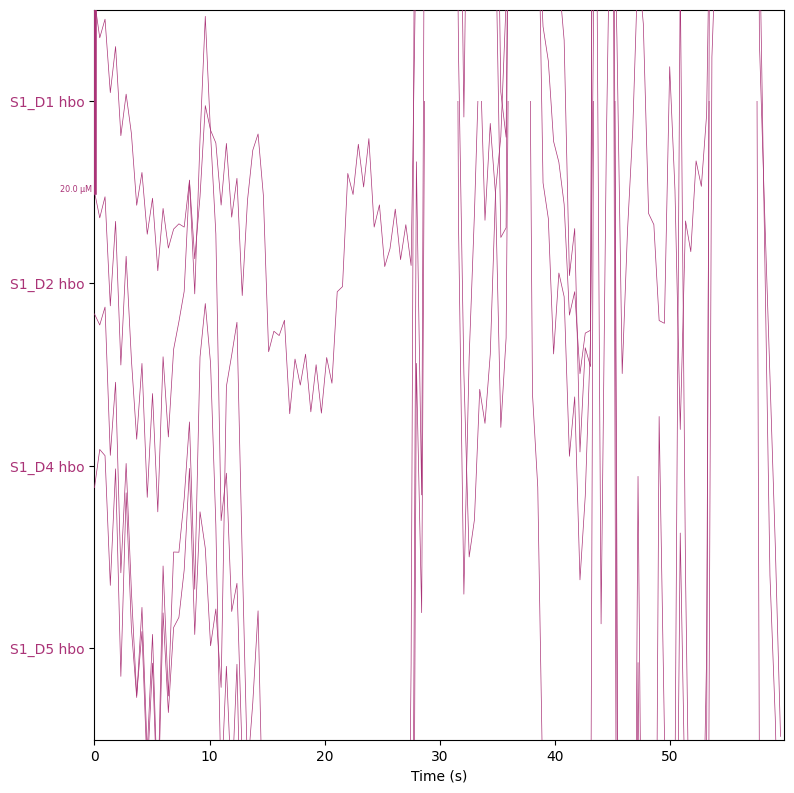

Data shape for ML: (200, 2656)


In [12]:
# 1. Load the dataset (Update the path to your downloaded SNIRF file)
# Example: 'sub-01/nirs/sub-01_task-ball_squeezing_nirs.snirf'
file_path = f'{target_folder}/sub-170/ses-01/nirs/sub-170_ses-01_task-Resting_nirs.snirf'
raw_intensity = mne.io.read_raw_snirf(file_path, preload=True)

# 2. Convert Raw Intensity to Optical Density (OD)
# This is a standard step before calculating Hemoglobin concentration
raw_od = mne.preprocessing.nirs.optical_density(raw_intensity)

# 3. Clean the data (Crucial for your Deep Learning input)
# We apply a bandpass filter (0.01 to 0.7 Hz) to isolate the hemodynamic response
raw_od.filter(0.01, 0.7, fir_design='firwin')

# 4. Convert Optical Density to Hemoglobin (HbO and HbR)
# This uses the Modified Beer-Lambert Law (MBLL)
raw_haemo = mne.preprocessing.nirs.beer_lambert_law(raw_od, ppf=0.1)

# 5. Visualize the cleaned signal
# This will show you the Red and IR light changes over time
raw_haemo.plot(n_channels=4, duration=60, show_scrollbars=False)
plt.show()

# 6. Prepare data for Deep Learning (NumPy Conversion)
# You can extract the data as a NumPy array for your CNN/LSTM training
data = raw_haemo.get_data() # Shape: (channels, time_points)
print(f"Data shape for ML: {data.shape}")